# Main V2 — GC-CNN Seizure Prediction (Improved Pipeline)

**Improvements over V1:**

| # | Change | Why |
|---|--------|-----|
| 1 | **Binary Focal Loss** (γ=2) | Focuses harder on misclassified minority examples vs plain weighted BCE |
| 2 | **GC matrix z-score normalisation** | StandardScaler fit on train only — makes GC scales comparable across patients |
| 3 | **Per-patient balanced sampler** | Caps each patient's contribution per epoch — prevents large patients dominating |
| 4 | **LR decay** (×0.9 per epoch) | Smoother convergence near optimum |
| 5 | **Patient-specific evaluation** | New: train+test on same patient (70/10/20) — establishes upper bound |

**Three evaluation outputs:**
1. LOPO V2 (primary)
2. Pooled baseline V2 (reference)
3. Patient-specific V2 (upper bound)

Plus a V1 vs V2 comparison if `results/lopo_results.csv` exists.

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# ── Cell 0: Imports & Config ──────────────────────────────────────────────────
# Uncomment on first run:
# !pip install mne torch scikit-learn numpy scipy pandas matplotlib --break-system-packages

import sys, os, copy, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Point at your code directory ──────────────────────────────────────────────
# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS,
    FS, LOWCUT, HIGHCUT, FILTER_ORDER,
    WINDOW_SEC, STEP_SEC, PREICTAL_SEC, SPH_SEC,
    POSTICTAL_EXCL_SEC, EXCLUDED_PATIENTS,
    RANDOM_SEED, RESULTS_DIR, GC_MATRICES_DIR
)
from summary_parser import parse_all_summaries
from granger        import compute_gc_matrices
from preprocessing  import bandpass_filter, segment_signal, label_windows
from data_loader    import load_edf
from metrics        import evaluate_predictions  # returns dict with key 'auc' (not 'auc_roc')

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── V2 hyperparameters ────────────────────────────────────────────────────────
V2_MAX_EPOCHS      = 50
V2_PATIENCE        = 10
V2_BATCH_SIZE      = 64
V2_LR              = 1e-3
V2_LR_DECAY        = 0.90       # ExponentialLR gamma
V2_FOCAL_GAMMA     = 2.0        # Binary Focal Loss focusing parameter
V2_VAL_FRACTION    = 0.15       # fraction of TRAIN pool used for validation
V2_MAX_WIN_PER_PAT = 600        # per-patient cap for balanced sampler

print(f'Device  : {DEVICE}')
print(f'Channels: {N_CHANNELS}  ({N_CHANNELS}x{N_CHANNELS} GC matrices)')
print(f'Focal gamma={V2_FOCAL_GAMMA} | LR={V2_LR} decay={V2_LR_DECAY}/epoch')
print(f'Max wins/patient/epoch = {V2_MAX_WIN_PER_PAT}')
print('V2 config loaded.')

Device  : cpu
Channels: 18  (18x18 GC matrices)
Focal gamma=2.0 | LR=0.001 decay=0.9/epoch
Max wins/patient/epoch = 600
V2 config loaded.


In [2]:
# ── Cell 1: Parse summaries ───────────────────────────────────────────────────
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Parsed summaries for {len(all_seizures)} files.')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# ── Cell 2: Load GC matrices ──────────────────────────────────────────────────
patient_data = {}

patients = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb')
    and p not in EXCLUDED_PATIENTS
])

for patient_id in patients:
    file_seizure_map = all_seizures.get(patient_id, {})
    if not file_seizure_map:
        continue

    print(f'\n{"─"*56}')
    print(f'Patient: {patient_id}')
    all_X, all_y = [], []

    for filename in sorted(file_seizure_map):
        seizures = file_seizure_map[filename]
        if not seizures:
            continue
        edf_path = os.path.join(DATA_ROOT, patient_id, filename)
        if not os.path.exists(edf_path):
            print(f'  [SKIP] {filename}: file not found')
            continue
        try:
            signal, fs = load_edf(edf_path)
        except Exception as e:
            print(f'  [SKIP] {filename}: {e}')
            continue

        filtered  = bandpass_filter(signal)
        windows   = segment_signal(filtered)
        n_samples = filtered.shape[1]
        labels    = label_windows(n_samples, seizures)

        valid   = labels != -1
        windows = windows[valid]
        labels  = labels[valid]

        if (labels == 1).sum() == 0:
            print(f'  [SKIP] {filename}: no preictal windows')
            continue

        matrices, _ = compute_gc_matrices(windows)
        all_X.append(matrices)
        all_y.append(labels)
        print(f'  [OK] {filename}  '
              f'preictal={(labels==1).sum()}  interictal={(labels==0).sum()}')

    if not all_X:
        print(f'  [SKIP] {patient_id}: no valid data')
        continue

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    patient_data[patient_id] = (X, y)
    print(f'  Done: {len(y)} windows  '
          f'preictal={(y==1).sum()}  interictal={(y==0).sum()}')

patient_ids = sorted(patient_data.keys())
print(f'\n{"="*56}')
print(f'Patients ready: {len(patient_ids)}')
print(patient_ids)


────────────────────────────────────────────────────────
Patient: chb01
  [OK] chb01_03.edf  preictal=148  interictal=146
    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
  [SKIP] chb01_04.edf: no preictal windows
    [LABEL] Seizure at 1732s: preictal window out of bounds (would start at -68s) — skipping preictal label.
  [SKIP] chb01_15.edf: no preictal windows
    [LABEL] Seizure at 1015s: preictal window out of bounds (would start at -785s) — skipping preictal label.
  [SKIP] chb01_16.edf: no preictal windows
    [LABEL] Seizure at 1720s: preictal window out of bounds (would start at -80s) — skipping preictal label.
  [SKIP] chb01_18.edf: no preictal windows
    [LABEL] Seizure at 327s: preictal window out of bounds (would start at -1473s) — skipping preictal label.
  [SKIP] chb01_21.edf: no preictal windows
  [OK] chb01_26.edf  preictal=148  interictal=33
  Done: 475 windows  preictal=296  interictal=179

──────────────

In [4]:
# ── Cell 3: V2 Model Components ───────────────────────────────────────────────

# ── Dataset ───────────────────────────────────────────────────────────────────
class GCDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,C,C)
        self.y = torch.tensor(y, dtype=torch.float32)               # (N,)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


# ── CNN (same architecture as V1) ─────────────────────────────────────────────
class GCPredictor(nn.Module):
    def __init__(self, n_channels=18, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            flat = self.features(torch.zeros(1, 1, n_channels, n_channels)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(flat, 256), nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.classifier(self.features(x))


# ── IMPROVEMENT 1: Binary Focal Loss ─────────────────────────────────────────
class BinaryFocalLoss(nn.Module):
    """FL = -alpha * (1-p_t)^gamma * log(p_t)"""
    def __init__(self, gamma=2.0, pos_weight=1.0):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, preds, targets):
        p     = preds.squeeze(1).clamp(1e-7, 1 - 1e-7)
        t     = targets.float()
        alpha = torch.where(t == 1,
                            torch.full_like(t, self.pos_weight),
                            torch.ones_like(t))
        bce   = -(t * torch.log(p) + (1 - t) * torch.log(1 - p))
        pt    = torch.where(t == 1, p, 1 - p)
        return (alpha * (1 - pt) ** self.gamma * bce).mean()


# ── IMPROVEMENT 3: Per-patient balanced sampler ───────────────────────────────
def make_balanced_sampler(patient_counts: list, max_per_patient: int):
    """
    Returns a WeightedRandomSampler that draws at most max_per_patient
    windows per patient per epoch.

    patient_counts : list of ints, each = number of training windows for that patient
                     in the same order they appear in the concatenated X_train.
    """
    weights = []
    for n in patient_counts:
        w = min(max_per_patient, n) / n   # downweight large patients
        weights.extend([w] * n)
    weights   = torch.tensor(weights, dtype=torch.float32)
    n_samples = len(patient_counts) * max_per_patient
    return WeightedRandomSampler(weights, num_samples=n_samples, replacement=True)


# ── Sanity check ──────────────────────────────────────────────────────────────
m = GCPredictor(N_CHANNELS).to(DEVICE)
assert m(torch.zeros(4, 1, N_CHANNELS, N_CHANNELS).to(DEVICE)).shape == (4, 1)
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
del m
print(f'GCPredictor OK  |  trainable params: {n_params:,}')
print(f'BinaryFocalLoss (gamma={V2_FOCAL_GAMMA}) ready')
print(f'Balanced sampler (max {V2_MAX_WIN_PER_PAT} wins/patient) ready')

GCPredictor OK  |  trainable params: 617,921
BinaryFocalLoss (gamma=2.0) ready
Balanced sampler (max 600 wins/patient) ready


In [5]:
# ── Cell 4: Training & inference ─────────────────────────────────────────────

def train_v2(X_train, y_train, X_val, y_val,
             patient_counts=None, verbose=True):
    """
    Train GCPredictor with V2 improvements.

    patient_counts : list of int (one per patient in training set, in concat order)
                     Pass None to skip balanced sampler (patient-specific mode).
    """
    set_seed()

    # Focal Loss + class frequency weight
    n_pos     = max(int((y_train == 1).sum()), 1)
    n_neg     = max(int((y_train == 0).sum()), 1)
    pos_w     = float(min(n_neg / n_pos, 50.0))
    criterion = BinaryFocalLoss(gamma=V2_FOCAL_GAMMA, pos_weight=pos_w).to(DEVICE)

    model     = GCPredictor(N_CHANNELS).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=V2_LR)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma=V2_LR_DECAY)

    train_ds  = GCDataset(X_train, y_train)
    val_ds    = GCDataset(X_val,   y_val)

    if patient_counts is not None:
        sampler  = make_balanced_sampler(patient_counts, V2_MAX_WIN_PER_PAT)
        train_dl = DataLoader(train_ds, batch_size=V2_BATCH_SIZE, sampler=sampler)
    else:
        train_dl = DataLoader(train_ds, batch_size=V2_BATCH_SIZE, shuffle=True)

    val_dl = DataLoader(val_ds, batch_size=V2_BATCH_SIZE, shuffle=False)

    best_val  = float('inf')
    best_wts  = None
    p_ctr     = 0

    for epoch in range(1, V2_MAX_EPOCHS + 1):
        model.train()
        tr_loss = 0.0
        for xb, yb in train_dl:
            xb, yb  = xb.to(DEVICE), yb.to(DEVICE)
            loss    = criterion(model(xb), yb)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            tr_loss += loss.item() * len(yb)
        tr_loss /= len(train_ds)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb   = xb.to(DEVICE), yb.to(DEVICE)
                va_loss += criterion(model(xb), yb).item() * len(yb)
        va_loss /= len(val_ds)

        scheduler.step()  # LR decay

        if verbose and epoch % 5 == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f'    Epoch {epoch:3d}/{V2_MAX_EPOCHS}  '
                  f'train={tr_loss:.4f}  val={va_loss:.4f}  lr={lr_now:.6f}')

        if va_loss < best_val - 1e-6:
            best_val  = va_loss
            best_wts  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            p_ctr     = 0
        else:
            p_ctr += 1
            if p_ctr >= V2_PATIENCE:
                if verbose: print(f'    Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(best_wts)
    return model


def predict_proba(model, X):
    """Return P(preictal) for each window in X."""
    model.eval()
    ds  = GCDataset(X, np.zeros(len(X)))
    dl  = DataLoader(ds, batch_size=V2_BATCH_SIZE, shuffle=False)
    out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(model(xb.to(DEVICE)).squeeze(1).cpu().numpy())
    return np.concatenate(out)


print('train_v2 and predict_proba ready.')

train_v2 and predict_proba ready.


In [6]:
# ── Cell 5: LOPO V2 ───────────────────────────────────────────────────────────

lopo_v2_results = {}
n_folds = len(patient_ids)

print('=' * 62)
print(f'LOPO V2  ({n_folds} folds)  |  device: {DEVICE}')
print('  + Focal Loss  + GC normalisation  + Balanced sampler  + LR decay')
print('=' * 62)

for fold_idx, test_pid in enumerate(patient_ids, 1):
    print(f'\n[Fold {fold_idx}/{n_folds}]  Test: {test_pid}')

    train_pids = [p for p in patient_ids if p != test_pid]

    # Collect training data, tracking per-patient window counts for the sampler
    X_parts, y_parts, raw_counts = [], [], []
    for p in train_pids:
        Xp, yp = patient_data[p]
        X_parts.append(Xp)
        y_parts.append(yp)
        raw_counts.append(len(yp))

    X_pool = np.concatenate(X_parts)
    y_pool = np.concatenate(y_parts)

    # Stratified validation split
    idx = np.arange(len(y_pool))
    tr_idx, va_idx = train_test_split(
        idx, test_size=V2_VAL_FRACTION,
        random_state=RANDOM_SEED, stratify=y_pool
    )
    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]
    X_te, y_te = patient_data[test_pid]

    # IMPROVEMENT 2: GC normalisation — fit on TRAIN only, apply to val + test
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr.reshape(len(X_tr), -1)).reshape(X_tr.shape)
    X_va   = scaler.transform(X_va.reshape(len(X_va), -1)).reshape(X_va.shape)
    X_te   = scaler.transform(X_te.reshape(len(X_te), -1)).reshape(X_te.shape)

    # Per-patient counts scaled to the train fraction
    train_frac    = len(tr_idx) / len(y_pool)
    train_counts  = [max(1, round(c * train_frac)) for c in raw_counts]

    print(f'  Train={len(y_tr)} (pre={(y_tr==1).sum()}, int={(y_tr==0).sum()})  '
          f'Val={len(y_va)}  Test={len(y_te)} (pre={(y_te==1).sum()})')

    model   = train_v2(X_tr, y_tr, X_va, y_va,
                       patient_counts=train_counts, verbose=True)
    scores  = predict_proba(model, X_te)
    metrics = evaluate_predictions(y_te, scores, threshold=0.5, patient_id=test_pid)
    lopo_v2_results[test_pid] = metrics

    print(f'  -> AUC={metrics["auc"]:.3f}  '
          f'Sens={metrics["sensitivity"]:.3f}  '
          f'Spec={metrics["specificity"]:.3f}  '
          f'F1={metrics["f1"]:.3f}  '
          f'FPR/h={metrics["fpr_per_hour"]:.1f}')

print(f'\n{"="*62}')
print('LOPO V2 complete.')

LOPO V2  (21 folds)  |  device: cpu
  + Focal Loss  + GC normalisation  + Balanced sampler  + LR decay

[Fold 1/21]  Test: chb01
  Train=26778 (pre=9020, int=17758)  Val=4726  Test=475 (pre=296)
    Epoch   5/50  train=0.0773  val=0.1708  lr=0.000590
    Epoch  10/50  train=0.0601  val=0.1607  lr=0.000349
    Epoch  15/50  train=0.0479  val=0.1441  lr=0.000206
    Epoch  20/50  train=0.0399  val=0.1469  lr=0.000122
    Epoch  25/50  train=0.0369  val=0.1413  lr=0.000072
    Epoch  30/50  train=0.0342  val=0.1441  lr=0.000042
    Epoch  35/50  train=0.0317  val=0.1459  lr=0.000025
    Early stopping at epoch 35.
  -> AUC=0.494  Sens=0.179  Spec=0.804  F1=0.276  FPR/h=70.4

[Fold 2/21]  Test: chb02
  Train=26652 (pre=9020, int=17632)  Val=4704  Test=623 (pre=296)
    Epoch   5/50  train=0.0736  val=0.1740  lr=0.000590
    Epoch  10/50  train=0.0577  val=0.1486  lr=0.000349
    Epoch  15/50  train=0.0438  val=0.1432  lr=0.000206
    Epoch  20/50  train=0.0370  val=0.1446  lr=0.000122
    

IndexError: index 26639 is out of bounds for dimension 0 with size 26639

In [7]:
# ── Cell 6: Patient-Specific V2 ───────────────────────────────────────────────
#
# IMPROVEMENT 5: Train and test on the SAME patient.
# Stratified 70 / 10 / 20 split.
# No cross-patient data — establishes upper bound on what GC-CNN can achieve.

ps_v2_results = {}

print('=' * 62)
print(f'Patient-Specific V2  ({len(patient_ids)} patients)')
print('  70% train / 10% val / 20% test  (stratified)')
print('=' * 62)

for pid in patient_ids:
    X_all, y_all = patient_data[pid]
    n     = len(y_all)
    n_pos = int((y_all == 1).sum())

    # Need at least 3 preictal per split; skip if too few
    if n < 30 or n_pos < 5:
        print(f'[SKIP] {pid}: n={n}, n_preictal={n_pos}')
        continue

    # Stratified 70/10/20
    idx = np.arange(n)
    tr_idx, tmp = train_test_split(
        idx, test_size=0.30,
        random_state=RANDOM_SEED, stratify=y_all
    )
    # tmp is 30%; split into ~10% val + ~20% test
    va_idx, te_idx = train_test_split(
        tmp, test_size=0.667,
        random_state=RANDOM_SEED, stratify=y_all[tmp]
    )

    X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
    X_va, y_va = X_all[va_idx], y_all[va_idx]
    X_te, y_te = X_all[te_idx], y_all[te_idx]

    # GC normalisation — fit on THIS patient's train only
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr.reshape(len(X_tr), -1)).reshape(X_tr.shape)
    X_va   = scaler.transform(X_va.reshape(len(X_va), -1)).reshape(X_va.shape)
    X_te   = scaler.transform(X_te.reshape(len(X_te), -1)).reshape(X_te.shape)

    print(f'\n[{pid}]  train={len(y_tr)} (pre={(y_tr==1).sum()})  '
          f'val={len(y_va)}  test={len(y_te)} (pre={(y_te==1).sum()})')

    # No balanced sampler for single patient (dataset is small)
    model   = train_v2(X_tr, y_tr, X_va, y_va,
                       patient_counts=None, verbose=False)
    scores  = predict_proba(model, X_te)
    metrics = evaluate_predictions(y_te, scores, threshold=0.5, patient_id=pid)
    ps_v2_results[pid] = metrics

    print(f'  AUC={metrics["auc"]:.3f}  '
          f'Sens={metrics["sensitivity"]:.3f}  '
          f'Spec={metrics["specificity"]:.3f}  '
          f'F1={metrics["f1"]:.3f}')

print(f'\nPatient-specific V2 complete.  ({len(ps_v2_results)} patients evaluated)')

Patient-Specific V2  (21 patients)
  70% train / 10% val / 20% test  (stratified)

[chb01]  train=332 (pre=207)  val=47  test=96 (pre=60)
  AUC=0.956  Sens=0.833  Spec=0.944  F1=0.893

[chb02]  train=436 (pre=207)  val=62  test=125 (pre=59)
  AUC=0.790  Sens=0.864  Spec=0.651  F1=0.767

[chb03]  train=460 (pre=310)  val=65  test=133 (pre=90)
  AUC=0.951  Sens=0.944  Spec=0.837  F1=0.934

[chb04]  train=1411 (pre=207)  val=201  test=405 (pre=59)
  AUC=0.868  Sens=0.814  Spec=0.708  F1=0.462

[chb05]  train=486 (pre=310)  val=69  test=140 (pre=90)
  AUC=0.926  Sens=0.833  Spec=0.880  F1=0.877

[chb06]  train=4522 (pre=726)  val=645  test=1294 (pre=208)
  AUC=0.890  Sens=0.865  Spec=0.742  F1=0.539

[chb07]  train=2053 (pre=311)  val=293  test=587 (pre=89)
  AUC=0.987  Sens=0.978  Spec=0.900  F1=0.770

[chb08]  train=893 (pre=519)  val=127  test=256 (pre=148)
  AUC=0.905  Sens=0.878  Spec=0.778  F1=0.861

[chb09]  train=1976 (pre=414)  val=282  test=565 (pre=119)
  AUC=0.948  Sens=0.840  

In [8]:
# ── Cell 7: Pooled Baseline V2 ────────────────────────────────────────────────

all_X = np.concatenate([patient_data[p][0] for p in patient_ids])
all_y = np.concatenate([patient_data[p][1] for p in patient_ids])

idx = np.arange(len(all_y))
tr_idx, tmp = train_test_split(
    idx, test_size=0.35,
    random_state=RANDOM_SEED, stratify=all_y
)
va_idx, te_idx = train_test_split(
    tmp, test_size=0.714,
    random_state=RANDOM_SEED, stratify=all_y[tmp]
)

X_tr, y_tr = all_X[tr_idx], all_y[tr_idx]
X_va, y_va = all_X[va_idx], all_y[va_idx]
X_te, y_te = all_X[te_idx], all_y[te_idx]

scaler = StandardScaler()
X_tr   = scaler.fit_transform(X_tr.reshape(len(X_tr), -1)).reshape(X_tr.shape)
X_va   = scaler.transform(X_va.reshape(len(X_va), -1)).reshape(X_va.shape)
X_te   = scaler.transform(X_te.reshape(len(X_te), -1)).reshape(X_te.shape)

print('=' * 62)
print(f'Pooled V2  |  Train={len(y_tr)}  Val={len(y_va)}  Test={len(y_te)}')
print(f'           |  preictal in test: {(y_te==1).sum()}')
print('=' * 62)

model_pooled  = train_v2(X_tr, y_tr, X_va, y_va,
                          patient_counts=None, verbose=True)
scores_pooled = predict_proba(model_pooled, X_te)
pooled_v2     = evaluate_predictions(y_te, scores_pooled,
                                      threshold=0.5, patient_id='pooled_v2')

print(f'\nPooled V2 -> AUC={pooled_v2["auc"]:.3f}  '
      f'Sens={pooled_v2["sensitivity"]:.3f}  '
      f'Spec={pooled_v2["specificity"]:.3f}  '
      f'F1={pooled_v2["f1"]:.3f}')

Pooled V2  |  Train=20786  Val=3201  Test=7992
           |  preictal in test: 2726
    Epoch   5/50  train=0.1524  val=0.1558  lr=0.000590
    Epoch  10/50  train=0.1023  val=0.1413  lr=0.000349
    Epoch  15/50  train=0.0689  val=0.1591  lr=0.000206
    Epoch  20/50  train=0.0509  val=0.1829  lr=0.000122
    Early stopping at epoch 20.

Pooled V2 -> AUC=0.900  Sens=0.859  Spec=0.767  F1=0.744


In [9]:
# ── Cell 8: Save all results ──────────────────────────────────────────────────

os.makedirs(RESULTS_DIR, exist_ok=True)
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'f1', 'balanced_accuracy', 'fpr_per_hour']

def to_df(results_dict, pid_list):
    rows = [
        {'patient': pid, **{k: results_dict[pid][k] for k in METRIC_KEYS}}
        for pid in pid_list if pid in results_dict
    ]
    df = pd.DataFrame(rows)
    df = pd.concat([
        df,
        pd.DataFrame([{'patient': 'MEAN', **{k: round(df[k].mean(), 4) for k in METRIC_KEYS}}]),
        pd.DataFrame([{'patient': 'STD',  **{k: round(df[k].std(),  4) for k in METRIC_KEYS}}])
    ], ignore_index=True)
    return df

lopo_v2_df = to_df(lopo_v2_results, patient_ids)
ps_v2_df   = to_df(ps_v2_results,   patient_ids)

lopo_v2_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v2_results.csv'), index=False)
ps_v2_df.to_csv(  os.path.join(RESULTS_DIR, 'patient_specific_v2.csv'), index=False)
pd.DataFrame([{'patient': 'pooled_v2', **{k: pooled_v2[k] for k in METRIC_KEYS}}]).to_csv(
    os.path.join(RESULTS_DIR, 'pooled_v2_results.csv'), index=False
)

print('='*62)
print('LOPO V2')
print('='*62)
print(lopo_v2_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\n' + '='*62)
print('Patient-Specific V2')
print('='*62)
print(ps_v2_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f'\nPooled V2  AUC={pooled_v2["auc"]:.4f}  '
      f'Sens={pooled_v2["sensitivity"]:.4f}  '
      f'Spec={pooled_v2["specificity"]:.4f}')
print(f'\nAll CSVs saved to {RESULTS_DIR}/')

LOPO V2
patient    auc  auc_pr  sensitivity  specificity     f1  balanced_accuracy  fpr_per_hour
  chb01 0.4936  0.6361       0.1791       0.8045 0.2760             0.4918       70.3911
  chb02 0.4766  0.4870       0.2500       0.7615 0.3304             0.5057       85.8716
  chb03 0.5347  0.7152       0.5518       0.4533 0.6079             0.5025      196.8224
  chb04 0.4002  0.1161       0.0878       0.8158 0.0814             0.4518       66.3103
  chb05 0.4160  0.5707       0.1622       0.6892 0.2424             0.4257      111.8725
  chb06 0.5792  0.1906       0.2430       0.8173 0.2211             0.5302       65.7743
  chb07 0.5577  0.1726       0.6629       0.3939 0.2625             0.5284      218.1994
  chb08 0.5899  0.6383       0.6491       0.4841 0.6422             0.5666      185.7196
  chb09 0.4967  0.2055       0.5169       0.4680 0.2935             0.4924      191.5374
  chb10 0.5775  0.3311       0.7849       0.2573 0.4024             0.5211      267.3676
  chb13 0.528

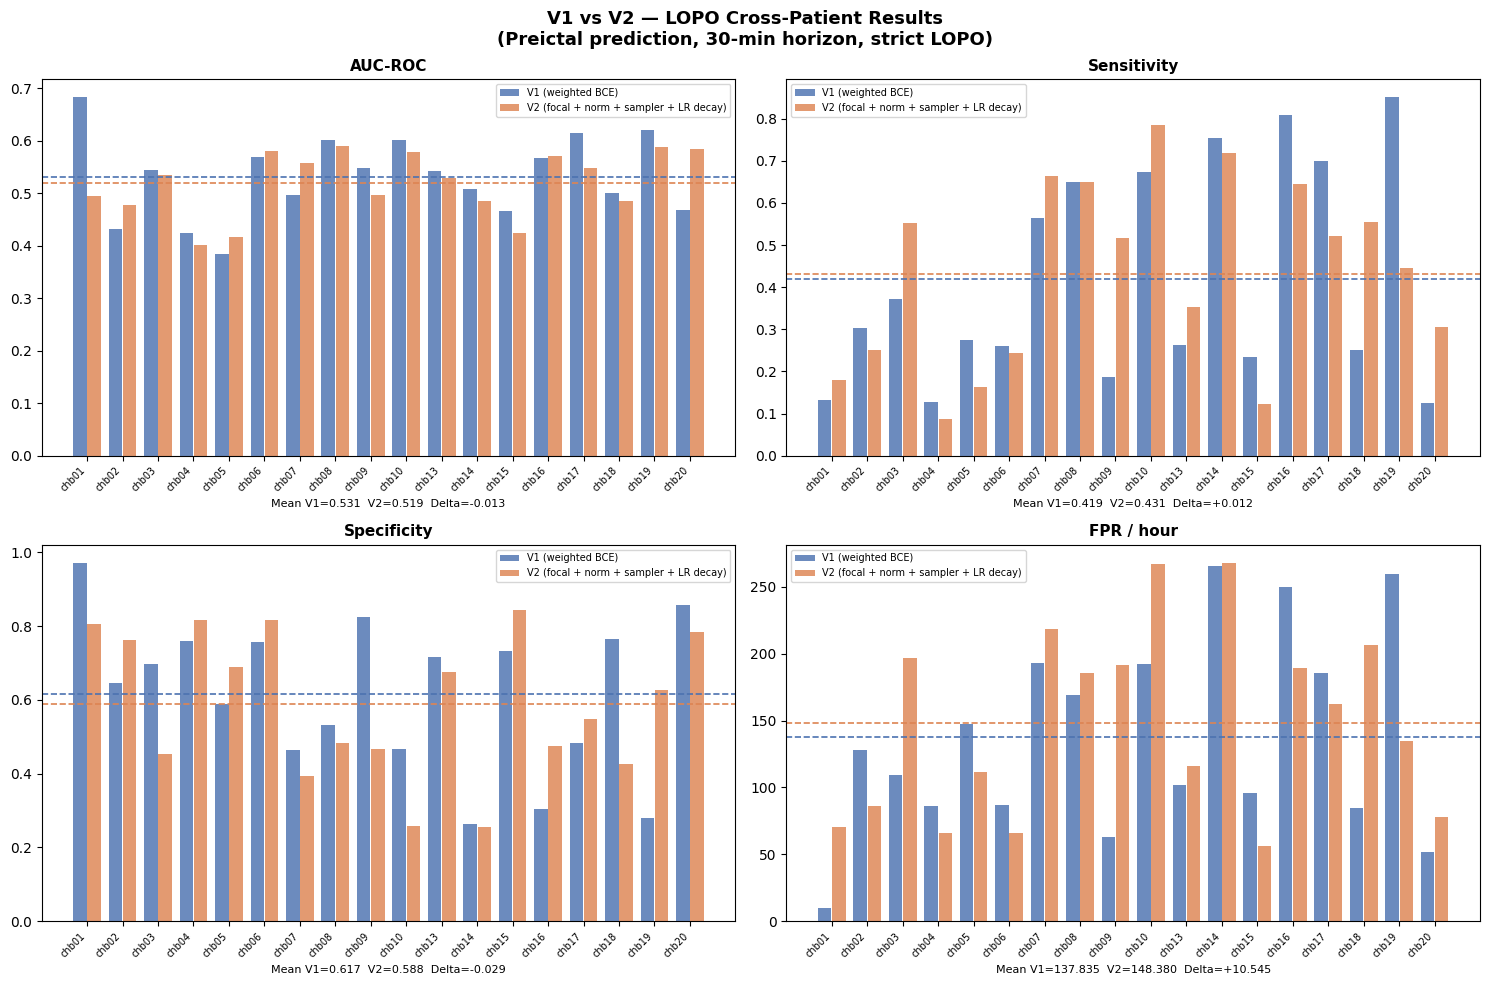

Comparison plot saved: results/v1_vs_v2_lopo.png


In [10]:
# ── Cell 9: V1 vs V2 LOPO comparison ─────────────────────────────────────────

v1_csv = os.path.join(RESULTS_DIR, 'lopo_results.csv')

if not os.path.exists(v1_csv):
    print(f'V1 results not found at {v1_csv} — run main V1 notebook first.')
else:
    v1_df = pd.read_csv(v1_csv)
    # Normalise patient column name across different save formats
    pid_col = [c for c in v1_df.columns if 'patient' in c.lower()][0]
    v1_df   = v1_df.rename(columns={pid_col: 'patient'})
    v1_df   = v1_df[~v1_df['patient'].astype(str).isin(['MEAN', 'STD'])].copy()

    v2_plot = lopo_v2_df[~lopo_v2_df['patient'].isin(['MEAN', 'STD'])].copy()

    compare = ['auc', 'sensitivity', 'specificity', 'fpr_per_hour']
    titles  = ['AUC-ROC', 'Sensitivity', 'Specificity', 'FPR / hour']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for ax, metric, title in zip(axes.flat, compare, titles):
        pids = v2_plot['patient'].tolist()
        x    = np.arange(len(pids))

        v1_vals, v2_vals = [], []
        for p in pids:
            r1 = v1_df[v1_df['patient'] == p]
            v1_vals.append(float(r1[metric].values[0]) if (len(r1) and metric in v1_df.columns) else np.nan)
            r2 = v2_plot[v2_plot['patient'] == p]
            v2_vals.append(float(r2[metric].values[0]) if len(r2) else np.nan)

        m1, m2 = np.nanmean(v1_vals), np.nanmean(v2_vals)
        delta  = m2 - m1
        sign   = '+' if delta >= 0 else ''

        ax.bar(x - 0.2, v1_vals, 0.38, label='V1 (weighted BCE)',
               color='#4C72B0', alpha=0.82)
        ax.bar(x + 0.2, v2_vals, 0.38,
               label='V2 (focal + norm + sampler + LR decay)',
               color='#DD8452', alpha=0.82)
        ax.axhline(m1, color='#4C72B0', linestyle='--', linewidth=1.2)
        ax.axhline(m2, color='#DD8452', linestyle='--', linewidth=1.2)
        ax.set_xticks(x)
        ax.set_xticklabels(pids, rotation=45, ha='right', fontsize=7)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=7)
        ax.set_xlabel(f'Mean V1={m1:.3f}  V2={m2:.3f}  Delta={sign}{delta:.3f}',
                      fontsize=8)

    plt.suptitle('V1 vs V2 — LOPO Cross-Patient Results\n'
                 '(Preictal prediction, 30-min horizon, strict LOPO)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, 'v1_vs_v2_lopo.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Comparison plot saved: {out}')

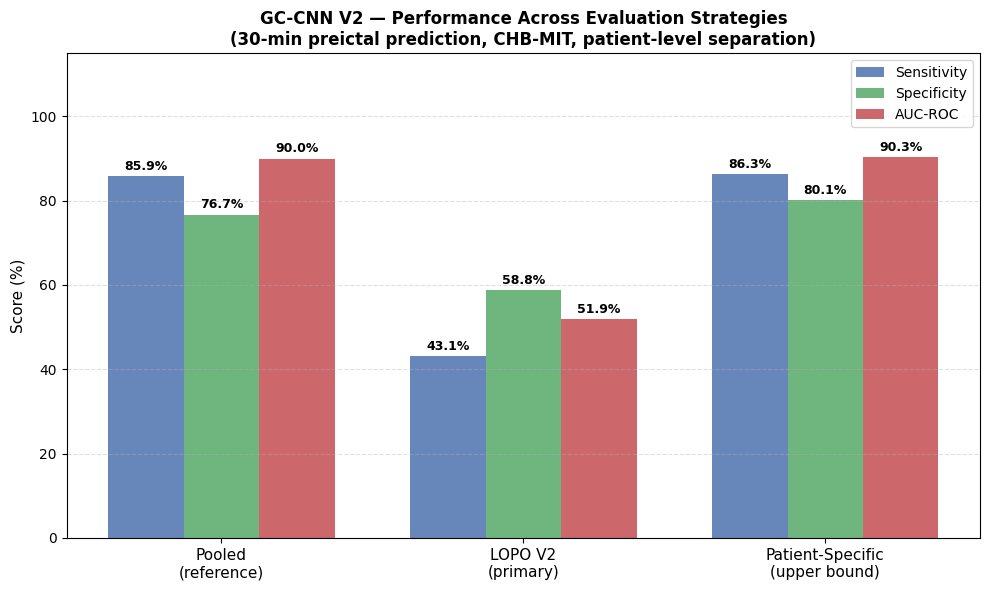

Three-tier summary saved: results/v2_three_tier_summary.png

V2 FINAL SUMMARY
Pooled (reference)                Sens=85.9%  Spec=76.7%  AUC=90.0%
LOPO V2 (primary)                 Sens=43.1%  Spec=58.8%  AUC=51.9%
Patient-Specific (upper bound)    Sens=86.3%  Spec=80.1%  AUC=90.3%
LOPO V2 mean AUC  : 0.519 +/- 0.060
LOPO V2 mean FPR/h: 148.4


In [11]:
# ── Cell 10: Three-tier summary plot ─────────────────────────────────────────
#
# Pooled (reference) / LOPO V2 (primary) / Patient-Specific (upper bound)

lopo_pids = [p for p in patient_ids if p in lopo_v2_results]
ps_pids   = [p for p in patient_ids if p in ps_v2_results]

vals = {
    'Sensitivity': [
        pooled_v2['sensitivity'],
        np.mean([lopo_v2_results[p]['sensitivity'] for p in lopo_pids]),
        np.mean([ps_v2_results[p]['sensitivity']   for p in ps_pids]),
    ],
    'Specificity': [
        pooled_v2['specificity'],
        np.mean([lopo_v2_results[p]['specificity'] for p in lopo_pids]),
        np.mean([ps_v2_results[p]['specificity']   for p in ps_pids]),
    ],
    'AUC-ROC': [
        pooled_v2['auc'],
        np.mean([lopo_v2_results[p]['auc']         for p in lopo_pids]),
        np.mean([ps_v2_results[p]['auc']           for p in ps_pids]),
    ],
}

strategies = ['Pooled\n(reference)', 'LOPO V2\n(primary)', 'Patient-Specific\n(upper bound)']
x          = np.arange(len(strategies))
w          = 0.25
colors     = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metric, v) in enumerate(vals.items()):
    bars = ax.bar(x + (i - 1) * w, [vi * 100 for vi in v], w,
                  label=metric, color=colors[i], alpha=0.85)
    for bar, vi in zip(bars, v):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{vi*100:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title(
    'GC-CNN V2 — Performance Across Evaluation Strategies\n'
    '(30-min preictal prediction, CHB-MIT, patient-level separation)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

out = os.path.join(RESULTS_DIR, 'v2_three_tier_summary.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Three-tier summary saved: {out}')

# ── Text summary ──────────────────────────────────────────────────────────────
print('\n' + '='*62)
print('V2 FINAL SUMMARY')
print('='*62)
for strat, s, sp, a in zip(strategies,
                            vals['Sensitivity'],
                            vals['Specificity'],
                            vals['AUC-ROC']):
    label = strat.replace('\n', ' ')
    print(f'{label:32s}  Sens={s*100:.1f}%  Spec={sp*100:.1f}%  AUC={a*100:.1f}%')
print('='*62)
lopo_aucs = [lopo_v2_results[p]['auc'] for p in lopo_pids]
print(f'LOPO V2 mean AUC  : {np.mean(lopo_aucs):.3f} +/- {np.std(lopo_aucs):.3f}')
lopo_fprs = [lopo_v2_results[p]['fpr_per_hour'] for p in lopo_pids]
print(f'LOPO V2 mean FPR/h: {np.mean(lopo_fprs):.1f}')